In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns

In [2]:
CONCEPTS = ['bald', 'chubby', 'eyeglasses', 'male', 'wearing_hat']

In [3]:
concept = CONCEPTS[2]

In [4]:
concept_info = dict([(concept, dict()) for concept in CONCEPTS])

In [10]:
debias_methods = ['diff_means', 'lr', 'pclarc']

In [11]:
results = []

for concept in CONCEPTS:
    concept_info = dict()

    df = pd.read_csv(rf'./Notebooks/results/zero_shot_eval/{concept}/results.csv')
    df = df[df['regime'] == 'single'].reset_index(drop=True)
    df['bal_acc'] = np.maximum(0.5, df['bal_acc'])

 
    target_equals_debiased_concept = (df['target_attribute'] == df['debiased_concept']).to_numpy()
    target_equals_debiased_concept = (df['target_attribute'] == concept).to_numpy()
    concept_df = df.iloc[target_equals_debiased_concept, :].reset_index(drop=True)

    # ommiting all of debiased concepts due to differences in detection
    other_df = df.iloc[~target_equals_debiased_concept, :].reset_index(drop=True)
    for _concept in CONCEPTS:
        other_df = other_df.iloc[~(other_df['target_attribute'] == _concept).to_numpy(), :]
    other_df.reset_index(drop=True, inplace=True)

    concept_df['delta_BA'] = concept_df['bal_acc'] - concept_df['ba_raw']

    for layer_index in range(24):
        layer_other = other_df.iloc[(other_df['debias_layer'] == layer_index).to_numpy(), :].reset_index(drop=True)
        concept_layer = concept_df.iloc[(concept_df['debias_layer'] == layer_index).to_numpy(), :].reset_index(drop=True)


        for debias_method in debias_methods:
            _other_df = layer_other.iloc[(layer_other['method'] == debias_method).to_numpy(), :].reset_index(drop=True)
            _concept_df = concept_layer.iloc[(concept_layer['method'] == debias_method).to_numpy(), :].reset_index(drop=True)

            mean_delta_concept_BA = _concept_df['delta_BA'].mean()
            mean_other_BA = _other_df['bal_acc'].mean()
            other_BA_sd = _other_df['bal_acc'].std()
            procedure_name = f'[single]_[{layer_index:02d}]_[{debias_method}]'
            base_concept_BA = _concept_df['ba_raw'].mean()
            debiased_concept_BA_mean = _concept_df['bal_acc'].mean()

            deleted_fraction = -(_concept_df['delta_BA'] / (_concept_df['ba_raw'] - 0.5)).mean()

            results.append((procedure_name, concept, -mean_delta_concept_BA, deleted_fraction, mean_other_BA, other_BA_sd, base_concept_BA, debiased_concept_BA_mean))

In [12]:
summarization = pd.DataFrame(results, columns = ['procedure_name', 'concept', 'debias_delta_BA_mean', 'debias_deleted_fraction_mean', 'other_BA_mean', 'other_BA_sd', 'base_concept_BA', 'debiased_concept_BA_mean'])

In [13]:
summarization.iloc[summarization['procedure_name'].str.contains('23').to_numpy(), :]

,procedure_name,concept,debias_delta_BA_mean,debias_deleted_fraction_mean,other_BA_mean,other_BA_sd,base_concept_BA,debiased_concept_BA_mean
69,[single]_[23]_[diff_means],bald,0.226562,0.950820,0.611900,0.107973,0.738281,0.511719
70,[single]_[23]_[lr],bald,0.152344,0.639344,0.615587,0.113270,0.738281,0.585938
71,[single]_[23]_[pclarc],bald,0.230469,0.967213,0.608906,0.107776,0.738281,0.507812
141,[single]_[23]_[diff_means],chubby,0.078125,0.500000,0.597712,0.103183,0.656250,0.578125
142,[single]_[23]_[lr],chubby,0.003906,0.025000,0.612238,0.111983,0.656250,0.652344
143,[single]_[23]_[pclarc],chubby,0.066406,0.425000,0.601341,0.103071,0.656250,0.589844
213,[single]_[23]_[diff_means],eyeglasses,0.351562,0.900000,0.609053,0.108225,0.890625,0.539062
214,[single]_[23]_[lr],eyeglasses,0.277344,0.710000,0.617331,0.112295,0.890625,0.613281
215,[single]_[23]_[pclarc],eyeglasses,0.355469,0.910000,0.611650,0.107671,0.890625,0.535156
285,[single]_[23]_[diff_means],male,0.472656,0.968000,0.602377,0.103373,0.988281,0.515625


In [15]:
df = pd.read_csv('./Notebooks/results/zero_shot_eval/eyeglasses/results.csv')
pos = 3000
df.iloc[pos:pos+20, :]

,target_attribute,bal_acc,auc,regime,debiased_concept,method,debias_layer,ba_raw,delta_ba,n_iterations,n_layers
3000,5_o_clock_shadow,0.559626,0.612787,sequential,eyeglasses,pclarc,-1,0.519397,0.040230,NaN,NaN
3001,arched_eyebrows,0.534739,0.555004,sequential,eyeglasses,pclarc,-1,0.562685,-0.027945,NaN,NaN
3002,attractive,0.506631,0.538060,sequential,eyeglasses,pclarc,-1,0.503774,0.002857,NaN,NaN
3003,bags_under_eyes,0.491657,0.431885,sequential,eyeglasses,pclarc,-1,0.499725,-0.008067,NaN,NaN
3004,bald,0.772071,0.881492,sequential,eyeglasses,pclarc,-1,0.791679,-0.019608,NaN,NaN
3005,bangs,0.803846,0.869231,sequential,eyeglasses,pclarc,-1,0.791137,0.012709,NaN,NaN
3006,big_lips,0.512176,0.505176,sequential,eyeglasses,pclarc,-1,0.493394,0.018781,NaN,NaN
3007,big_nose,0.551439,0.583206,sequential,eyeglasses,pclarc,-1,0.603896,-0.052457,NaN,NaN
3008,black_hair,0.755360,0.874250,sequential,eyeglasses,pclarc,-1,0.762436,-0.007075,NaN,NaN
3009,blond_hair,0.893212,0.925228,sequential,eyeglasses,pclarc,-1,0.823911,0.069301,NaN,NaN


In [16]:
df['regime'].value_counts()

regime
single                  2880
iterative_all_layers    1920
sequential               120
fixed_multi              120
iterative                 80
raw                       40
Name: count, dtype: int64

In [17]:
results = []

for concept in CONCEPTS:
    concept_info = dict()

    df = pd.read_csv(rf'./Notebooks/results/zero_shot_eval/{concept}/results.csv')
    df = df[df['regime'] == 'sequential'].reset_index(drop=True)
    df['bal_acc'] = np.maximum(0.5, df['bal_acc'])

 
    target_equals_debiased_concept = (df['target_attribute'] == df['debiased_concept']).to_numpy()
    target_equals_debiased_concept = (df['target_attribute'] == concept).to_numpy()
    concept_df = df.iloc[target_equals_debiased_concept, :].reset_index(drop=True)

    # ommiting all of debiased concepts due to differences in detection
    other_df = df.iloc[~target_equals_debiased_concept, :].reset_index(drop=True)
    for _concept in CONCEPTS:
        other_df = other_df.iloc[~(other_df['target_attribute'] == _concept).to_numpy(), :]
    other_df.reset_index(drop=True, inplace=True)

    concept_df['delta_BA'] = concept_df['bal_acc'] - concept_df['ba_raw']


    for debias_method in debias_methods:
        _other_df = other_df.iloc[(other_df['method'] == debias_method).to_numpy(), :].reset_index(drop=True)
        _concept_df = concept_df.iloc[(concept_df['method'] == debias_method).to_numpy(), :].reset_index(drop=True)

        mean_delta_concept_BA = _concept_df['delta_BA'].mean()
        mean_other_BA = _other_df['bal_acc'].mean()
        other_BA_sd = _other_df['bal_acc'].std()
        procedure_name = f'[sequential]_[{debias_method}]'
        base_concept_BA = _concept_df['ba_raw'].mean()
        debiased_concept_BA_mean = _concept_df['bal_acc'].mean()

        deleted_fraction = -(_concept_df['delta_BA'] / (_concept_df['ba_raw'] - 0.5)).mean()

        results.append((procedure_name, concept, -mean_delta_concept_BA, deleted_fraction, mean_other_BA, other_BA_sd, base_concept_BA, debiased_concept_BA_mean))

In [18]:
summarization2 = pd.DataFrame(results, columns = ['procedure_name', 'concept', 'debias_delta_BA_mean', 'debias_deleted_fraction_mean', 'other_BA_mean', 'other_BA_sd', 'base_concept_BA', 'debiased_concept_BA_mean'])
summarization2

,procedure_name,concept,debias_delta_BA_mean,debias_deleted_fraction_mean,other_BA_mean,other_BA_sd,base_concept_BA,debiased_concept_BA_mean
0,[sequential]_[diff_means],bald,0.222656,0.934426,0.611347,0.112084,0.738281,0.515625
1,[sequential]_[lr],bald,0.195312,0.819672,0.611333,0.109121,0.738281,0.542969
2,[sequential]_[pclarc],bald,0.226562,0.950820,0.614307,0.109431,0.738281,0.511719
3,[sequential]_[diff_means],chubby,0.074219,0.475000,0.597018,0.105439,0.656250,0.582031
4,[sequential]_[lr],chubby,0.039062,0.250000,0.606794,0.109964,0.656250,0.617188
5,[sequential]_[pclarc],chubby,0.058594,0.375000,0.600492,0.103505,0.656250,0.597656
6,[sequential]_[diff_means],eyeglasses,0.355469,0.910000,0.608440,0.112486,0.890625,0.535156
7,[sequential]_[lr],eyeglasses,0.339844,0.870000,0.612329,0.115890,0.890625,0.550781
8,[sequential]_[pclarc],eyeglasses,0.367188,0.940000,0.614931,0.116108,0.890625,0.523438
9,[sequential]_[diff_means],male,0.445312,0.912000,0.599261,0.103212,0.988281,0.542969


In [19]:
df = pd.read_csv('./Notebooks/results/zero_shot_eval/eyeglasses/results.csv')
df['regime'].value_counts()

regime
single                  2880
iterative_all_layers    1920
sequential               120
fixed_multi              120
iterative                 80
raw                       40
Name: count, dtype: int64

In [20]:
df[df['regime'] == 'fixed_multi']

,target_attribute,bal_acc,auc,regime,debiased_concept,method,debias_layer,ba_raw,delta_ba,n_iterations,n_layers
3120,5_o_clock_shadow,0.502874,0.560704,fixed_multi,eyeglasses,diff_means,6,0.519397,-0.016523,NaN,6.0
3121,arched_eyebrows,0.577809,0.594352,fixed_multi,eyeglasses,diff_means,6,0.562685,0.015125,NaN,6.0
3122,attractive,0.503774,0.567690,fixed_multi,eyeglasses,diff_means,6,0.503774,0.000000,NaN,6.0
3123,bags_under_eyes,0.467638,0.441786,fixed_multi,eyeglasses,diff_means,6,0.499725,-0.032087,NaN,6.0
3124,bald,0.781875,0.881396,fixed_multi,eyeglasses,diff_means,6,0.791679,-0.009804,NaN,6.0
...,...,...,...,...,...,...,...,...,...,...,...
3235,wearing_hat,0.904607,0.931377,fixed_multi,eyeglasses,pclarc,6,0.904607,0.000000,NaN,6.0
3236,wearing_lipstick,0.429688,0.384196,fixed_multi,eyeglasses,pclarc,6,0.421875,0.007812,NaN,6.0
3237,wearing_necklace,0.527737,0.533075,fixed_multi,eyeglasses,pclarc,6,0.529921,-0.002183,NaN,6.0
3238,wearing_necktie,0.561027,0.630260,fixed_multi,eyeglasses,pclarc,6,0.563125,-0.002098,NaN,6.0


In [21]:
results = []

for concept in CONCEPTS:
    concept_info = dict()

    df = pd.read_csv(rf'./Notebooks/results/zero_shot_eval/{concept}/results.csv')
    df = df[df['regime'] == 'fixed_multi'].reset_index(drop=True)
    df['bal_acc'] = np.maximum(0.5, df['bal_acc'])

 
    target_equals_debiased_concept = (df['target_attribute'] == df['debiased_concept']).to_numpy()
    target_equals_debiased_concept = (df['target_attribute'] == concept).to_numpy()
    concept_df = df.iloc[target_equals_debiased_concept, :].reset_index(drop=True)

    # ommiting all of debiased concepts due to differences in detection
    other_df = df.iloc[~target_equals_debiased_concept, :].reset_index(drop=True)
    for _concept in CONCEPTS:
        other_df = other_df.iloc[~(other_df['target_attribute'] == _concept).to_numpy(), :]
    other_df.reset_index(drop=True, inplace=True)

    concept_df['delta_BA'] = concept_df['bal_acc'] - concept_df['ba_raw']

    print()


    for debias_method in debias_methods:
        _other_df = other_df.iloc[(other_df['method'] == debias_method).to_numpy(), :].reset_index(drop=True)
        _concept_df = concept_df.iloc[(concept_df['method'] == debias_method).to_numpy(), :].reset_index(drop=True)

        mean_delta_concept_BA = _concept_df['delta_BA'].mean()
        mean_other_BA = _other_df['bal_acc'].mean()
        other_BA_sd = _other_df['bal_acc'].std()
        procedure_name = f'[fixed_multi]_[6]_[6]_[{debias_method}]'
        base_concept_BA = _concept_df['ba_raw'].mean()
        debiased_concept_BA_mean = _concept_df['bal_acc'].mean()

        deleted_fraction = -(_concept_df['delta_BA'] / (_concept_df['ba_raw'] - 0.5)).mean()

        results.append((procedure_name, concept, -mean_delta_concept_BA, deleted_fraction, mean_other_BA, other_BA_sd, base_concept_BA, debiased_concept_BA_mean))

In [22]:
summarization3 = pd.DataFrame(results, columns = ['procedure_name', 'concept', 'debias_delta_BA_mean', 'debias_deleted_fraction_mean', 'other_BA_mean', 'other_BA_sd', 'base_concept_BA', 'debiased_concept_BA_mean'])
summarization3

,procedure_name,concept,debias_delta_BA_mean,debias_deleted_fraction_mean,other_BA_mean,other_BA_sd,base_concept_BA,debiased_concept_BA_mean
0,[fixed_multi]_[6]_[6]_[diff_means],bald,0.003906,0.016393,0.620406,0.115894,0.738281,0.734375
1,[fixed_multi]_[6]_[6]_[lr],bald,0.007812,0.032787,0.619484,0.116234,0.738281,0.730469
2,[fixed_multi]_[6]_[6]_[pclarc],bald,0.003906,0.016393,0.620885,0.117274,0.738281,0.734375
3,[fixed_multi]_[6]_[6]_[diff_means],chubby,-0.007812,-0.050000,0.614465,0.113043,0.656250,0.664062
4,[fixed_multi]_[6]_[6]_[lr],chubby,-0.007812,-0.050000,0.614749,0.112276,0.656250,0.664062
5,[fixed_multi]_[6]_[6]_[pclarc],chubby,-0.003906,-0.025000,0.612055,0.111189,0.656250,0.660156
6,[fixed_multi]_[6]_[6]_[diff_means],eyeglasses,-0.019531,-0.050000,0.610739,0.112910,0.890625,0.910156
7,[fixed_multi]_[6]_[6]_[lr],eyeglasses,-0.023438,-0.060000,0.611273,0.112601,0.890625,0.914062
8,[fixed_multi]_[6]_[6]_[pclarc],eyeglasses,-0.019531,-0.050000,0.610666,0.112251,0.890625,0.910156
9,[fixed_multi]_[6]_[6]_[diff_means],male,-0.000000,-0.000000,0.614147,0.113363,0.988281,0.988281


In [23]:
df = pd.read_csv('./Notebooks/results/zero_shot_eval/eyeglasses/results.csv')
df['regime'].value_counts()

regime
single                  2880
iterative_all_layers    1920
sequential               120
fixed_multi              120
iterative                 80
raw                       40
Name: count, dtype: int64

In [24]:
results = []

for concept in CONCEPTS:
    concept_info = dict()

    df = pd.read_csv(rf'./Notebooks/results/zero_shot_eval/{concept}/results.csv')
    df = df[df['regime'] == 'iterative_all_layers'].reset_index(drop=True)
    df['bal_acc'] = np.maximum(0.5, df['bal_acc'])

 
    target_equals_debiased_concept = (df['target_attribute'] == df['debiased_concept']).to_numpy()
    target_equals_debiased_concept = (df['target_attribute'] == concept).to_numpy()
    concept_df = df.iloc[target_equals_debiased_concept, :].reset_index(drop=True)

    # ommiting all of debiased concepts due to differences in detection
    other_df = df.iloc[~target_equals_debiased_concept, :].reset_index(drop=True)
    for _concept in CONCEPTS:
        other_df = other_df.iloc[~(other_df['target_attribute'] == _concept).to_numpy(), :]
    other_df.reset_index(drop=True, inplace=True)

    concept_df['delta_BA'] = concept_df['bal_acc'] - concept_df['ba_raw']

    for layer_index in range(24):
        layer_other = other_df.iloc[(other_df['debias_layer'] == layer_index).to_numpy(), :].reset_index(drop=True)
        concept_layer = concept_df.iloc[(concept_df['debias_layer'] == layer_index).to_numpy(), :].reset_index(drop=True)


        for debias_method in ['lr', 'pclarc']:
            _other_df = layer_other.iloc[(layer_other['method'] == debias_method).to_numpy(), :].reset_index(drop=True)
            _concept_df = concept_layer.iloc[(concept_layer['method'] == debias_method).to_numpy(), :].reset_index(drop=True)

            mean_delta_concept_BA = _concept_df['delta_BA'].mean()
            mean_other_BA = _other_df['bal_acc'].mean()
            other_BA_sd = _other_df['bal_acc'].std()
            procedure_name = f'[iterative_all_layers]_[{layer_index:02d}]_[{debias_method}]'
            base_concept_BA = _concept_df['ba_raw'].mean()
            debiased_concept_BA_mean = _concept_df['bal_acc'].mean()

            deleted_fraction = -(_concept_df['delta_BA'] / (_concept_df['ba_raw'] - 0.5)).mean()

            results.append((procedure_name, concept, -mean_delta_concept_BA, deleted_fraction, mean_other_BA, other_BA_sd, base_concept_BA, debiased_concept_BA_mean))

In [25]:
summarization4 = pd.DataFrame(results, columns = ['procedure_name', 'concept', 'debias_delta_BA_mean', 'debias_deleted_fraction_mean', 'other_BA_mean', 'other_BA_sd', 'base_concept_BA', 'debiased_concept_BA_mean'])
summarization4.iloc[summarization4['procedure_name'].str.contains('23').to_numpy(), :]

,procedure_name,concept,debias_delta_BA_mean,debias_deleted_fraction_mean,other_BA_mean,other_BA_sd,base_concept_BA,debiased_concept_BA_mean
46,[iterative_all_layers]_[23]_[lr],bald,0.238281,1.000000,0.509411,0.021029,0.738281,0.500000
47,[iterative_all_layers]_[23]_[pclarc],bald,0.238281,1.000000,0.510750,0.022704,0.738281,0.500000
94,[iterative_all_layers]_[23]_[lr],chubby,0.140625,0.900000,0.520091,0.022777,0.656250,0.515625
95,[iterative_all_layers]_[23]_[pclarc],chubby,0.058594,0.375000,0.519746,0.021277,0.656250,0.597656
142,[iterative_all_layers]_[23]_[lr],eyeglasses,0.371094,0.950000,0.518429,0.027674,0.890625,0.519531
143,[iterative_all_layers]_[23]_[pclarc],eyeglasses,0.257812,0.660000,0.516148,0.028538,0.890625,0.632812
190,[iterative_all_layers]_[23]_[lr],male,0.445312,0.912000,0.514273,0.023662,0.988281,0.542969
191,[iterative_all_layers]_[23]_[pclarc],male,0.480469,0.984000,0.514116,0.022300,0.988281,0.507812
238,[iterative_all_layers]_[23]_[lr],wearing_hat,0.347656,0.927083,0.521411,0.044179,0.875000,0.527344
239,[iterative_all_layers]_[23]_[pclarc],wearing_hat,0.375000,1.000000,0.522000,0.043155,0.875000,0.500000


In [26]:
results = []

for concept in CONCEPTS:
    concept_info = dict()

    df = pd.read_csv(rf'./Notebooks/results/zero_shot_eval/{concept}/results.csv')
    df = df[df['regime'] == 'iterative'].reset_index(drop=True)
    df['bal_acc'] = np.maximum(0.5, df['bal_acc'])

 
    target_equals_debiased_concept = (df['target_attribute'] == df['debiased_concept']).to_numpy()
    target_equals_debiased_concept = (df['target_attribute'] == concept).to_numpy()
    concept_df = df.iloc[target_equals_debiased_concept, :].reset_index(drop=True)

    # ommiting all of debiased concepts due to differences in detection
    other_df = df.iloc[~target_equals_debiased_concept, :].reset_index(drop=True)
    for _concept in CONCEPTS:
        other_df = other_df.iloc[~(other_df['target_attribute'] == _concept).to_numpy(), :]
    other_df.reset_index(drop=True, inplace=True)

    concept_df['delta_BA'] = concept_df['bal_acc'] - concept_df['ba_raw']

    print()


    for debias_method in ['lr', 'pclarc']:
        _other_df = other_df.iloc[(other_df['method'] == debias_method).to_numpy(), :].reset_index(drop=True)
        _concept_df = concept_df.iloc[(concept_df['method'] == debias_method).to_numpy(), :].reset_index(drop=True)

        mean_delta_concept_BA = _concept_df['delta_BA'].mean()
        mean_other_BA = _other_df['bal_acc'].mean()
        other_BA_sd = _other_df['bal_acc'].std()
        procedure_name = f'[iterative]_[{debias_method}]'
        base_concept_BA = _concept_df['ba_raw'].mean()
        debiased_concept_BA_mean = _concept_df['bal_acc'].mean()

        deleted_fraction = -(_concept_df['delta_BA'] / (_concept_df['ba_raw'] - 0.5)).mean()

        results.append((procedure_name, concept, -mean_delta_concept_BA, deleted_fraction, mean_other_BA, other_BA_sd, base_concept_BA, debiased_concept_BA_mean))

In [27]:
summarization5 = pd.DataFrame(results, columns = ['procedure_name', 'concept', 'debias_delta_BA_mean', 'debias_deleted_fraction_mean', 'other_BA_mean', 'other_BA_sd', 'base_concept_BA', 'debiased_concept_BA_mean'])
summarization5

,procedure_name,concept,debias_delta_BA_mean,debias_deleted_fraction_mean,other_BA_mean,other_BA_sd,base_concept_BA,debiased_concept_BA_mean
0,[iterative]_[lr],bald,0.011719,0.049180,0.624718,0.114288,0.738281,0.726562
1,[iterative]_[pclarc],bald,0.003906,0.016393,0.624230,0.116003,0.738281,0.734375
2,[iterative]_[lr],chubby,0.007812,0.050000,0.606091,0.116006,0.656250,0.648438
3,[iterative]_[pclarc],chubby,0.007812,0.050000,0.606851,0.116370,0.656250,0.648438
4,[iterative]_[lr],eyeglasses,-0.027344,-0.070000,0.613054,0.111893,0.890625,0.917969
5,[iterative]_[pclarc],eyeglasses,-0.019531,-0.050000,0.611691,0.108902,0.890625,0.910156
6,[iterative]_[lr],male,-0.000000,-0.000000,0.617308,0.116391,0.988281,0.988281
7,[iterative]_[pclarc],male,-0.000000,-0.000000,0.618269,0.115875,0.988281,0.988281
8,[iterative]_[lr],wearing_hat,0.003906,0.010417,0.628045,0.110296,0.875000,0.871094
9,[iterative]_[pclarc],wearing_hat,-0.000000,-0.000000,0.629657,0.110083,0.875000,0.875000


In [29]:
summarization = pd.concat([summarization, summarization2, summarization3, summarization4, summarization5], axis=0)

In [35]:
summarization.head()

,procedure_name,concept,debias_delta_BA_mean,debias_deleted_fraction_mean,other_BA_mean,other_BA_sd,base_concept_BA,debiased_concept_BA_mean
0,[single]_[00]_[diff_means],bald,-0.000000,-0.000000,0.619073,0.115631,0.738281,0.738281
1,[single]_[00]_[lr],bald,0.007812,0.032787,0.621987,0.116543,0.738281,0.730469
2,[single]_[00]_[pclarc],bald,-0.000000,-0.000000,0.620599,0.115344,0.738281,0.738281
3,[single]_[01]_[diff_means],bald,-0.000000,-0.000000,0.621934,0.115861,0.738281,0.738281
4,[single]_[01]_[lr],bald,-0.000000,-0.000000,0.622931,0.116176,0.738281,0.738281


In [80]:
grouped = summarization.groupby('procedure_name')[summarization.columns[2:]].mean().reset_index().sort_values('debias_deleted_fraction_mean')

In [81]:
grouped

,procedure_name,debias_delta_BA_mean,debias_deleted_fraction_mean,other_BA_mean,other_BA_sd,base_concept_BA,debiased_concept_BA_mean
47,[iterative_all_layers]_[21]_[lr],-0.010156,-0.037914,0.599184,0.106438,0.829688,0.839844
45,[iterative_all_layers]_[20]_[lr],-0.007812,-0.029943,0.608350,0.112892,0.829688,0.837500
21,[iterative_all_layers]_[08]_[lr],-0.006250,-0.023529,0.612934,0.115076,0.829688,0.835938
42,[iterative_all_layers]_[18]_[pclarc],-0.007812,-0.020417,0.613579,0.113595,0.829688,0.837500
41,[iterative_all_layers]_[18]_[lr],-0.007812,-0.019221,0.612327,0.114011,0.829688,0.837500
...,...,...,...,...,...,...,...
55,[sequential]_[pclarc],0.273438,0.773997,0.607219,0.107626,0.829688,0.556250
53,[sequential]_[diff_means],0.271875,0.785869,0.606454,0.109790,0.829688,0.557813
52,[iterative_all_layers]_[23]_[pclarc],0.282031,0.803800,0.516552,0.027595,0.829688,0.547656
125,[single]_[23]_[diff_means],0.293750,0.845014,0.607962,0.106475,0.829688,0.535937


In [82]:
def pareto_front(df, x_col, y_col):
    """
    Maksymalizacja x i y.
    Zwraca obserwacje należące do frontu Pareto.
    """
    data = df[[x_col, y_col, "procedure_name"]].copy()

    pareto_mask = np.ones(len(data), dtype=bool)

    for i in range(len(data)):
        xi = data.iloc[i][x_col]
        yi = data.iloc[i][y_col]

        dominated = (
            (data[x_col] >= xi)
            & (data[y_col] >= yi)
            & (
                (data[x_col] > xi)
                | (data[y_col] > yi)
            )
        )

        # usuń sam punkt z porównania
        dominated.iloc[i] = False

        if dominated.any():
            pareto_mask[i] = False

    return data[pareto_mask]


PARETO FRONT: debias_delta_BA_mean vs other_BA_mean
[iterative_all_layers]_[14]_[lr]
[single]_[18]_[lr]
[single]_[11]_[lr]
[single]_[16]_[lr]
[iterative_all_layers]_[02]_[lr]
[single]_[19]_[lr]
[single]_[23]_[lr]
[sequential]_[lr]
[single]_[23]_[diff_means]
[iterative_all_layers]_[23]_[lr]


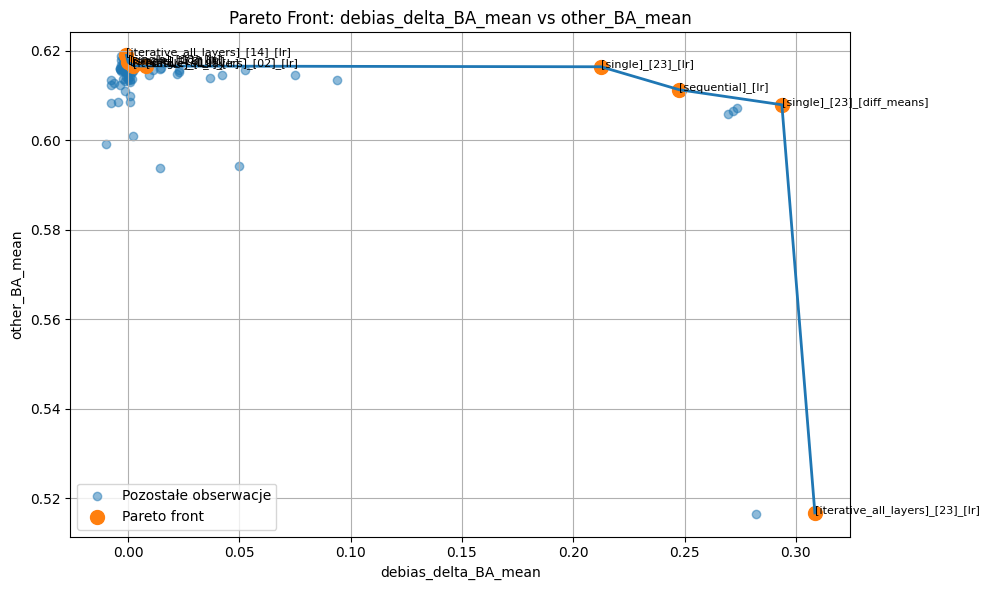


PARETO FRONT: debias_deleted_fraction_mean vs other_BA_mean
[iterative_all_layers]_[14]_[lr]
[iterative]_[lr]
[single]_[17]_[lr]
[single]_[19]_[lr]
[single]_[23]_[lr]
[sequential]_[lr]
[single]_[23]_[diff_means]
[iterative_all_layers]_[23]_[lr]


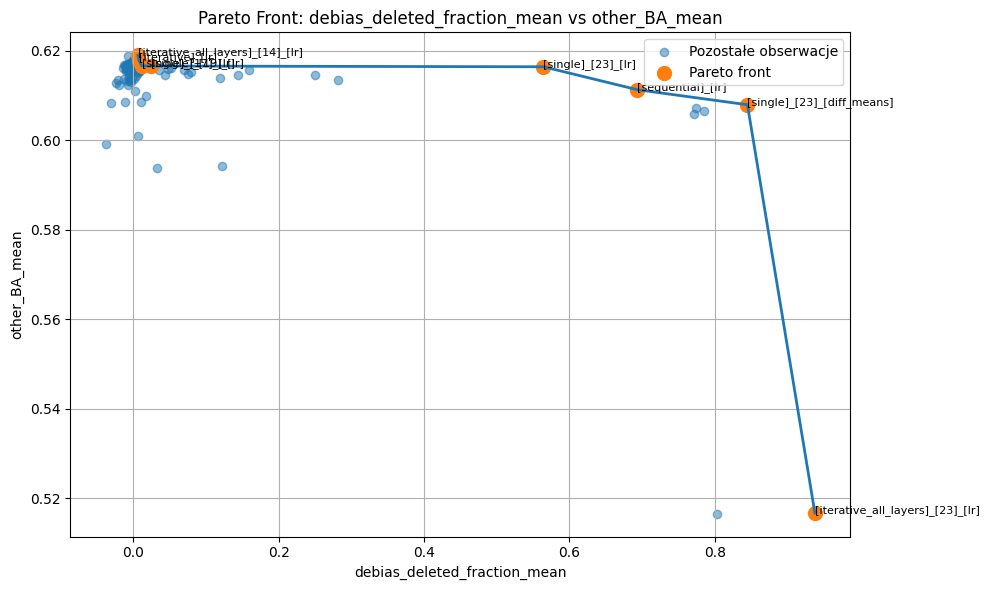

In [83]:
df = grouped
#df = grouped[~grouped['procedure_name'].str.contains('iterative').to_numpy()]

plots = [
    ("debias_delta_BA_mean", "other_BA_mean"),
    ("debias_deleted_fraction_mean", "other_BA_mean"),
]

for x_col, y_col in plots:

    pareto = pareto_front(df, x_col, y_col)

    pareto_sorted = pareto.sort_values(x_col)

    print(f"\n{'='*80}")
    print(f"PARETO FRONT: {x_col} vs {y_col}")
    print(f"{'='*80}")

    for proc in pareto_sorted["procedure_name"]:
        print(proc)

    plt.figure(figsize=(10, 6))

    plt.scatter(
        df[x_col],
        df[y_col],
        alpha=0.5,
        label="Pozostałe obserwacje"
    )

    plt.scatter(
        pareto_sorted[x_col],
        pareto_sorted[y_col],
        s=100,
        label="Pareto front"
    )

    plt.plot(
        pareto_sorted[x_col],
        pareto_sorted[y_col],
        linewidth=2
    )

    for _, row in pareto_sorted.iterrows():
        plt.annotate(
            row["procedure_name"],
            (row[x_col], row[y_col]),
            fontsize=8
        )

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"Pareto Front: {x_col} vs {y_col}")

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [129]:
results = []
for concept in CONCEPTS:
    df = pd.read_csv(rf'./Notebooks/results/zero_shot_eval/{concept}/results.csv')

    for _concept in CONCEPTS:
        df = df.iloc[(df['target_attribute'] != _concept).to_numpy()]

    results.append(('clip-vit-large-patch14', 0, 0, df['bal_acc'].mean(), df['bal_acc'].std(), np.nan, np.nan))
    
base_model = pd.DataFrame(results, columns = grouped.columns)

ValueError: 9 columns passed, passed data had 7 columns

In [ ]:
base_model = base_model.groupby('procedure_name').mean()

In [128]:
base_model.reset_index(inplace=True)


ValueError: cannot insert level_0, already exists

In [92]:
grouped['strategy'] = grouped['procedure_name'].str.split('_').str[0].str.replace('[', '').str.replace(']', '').str.lower()

In [97]:
grouped['debiasing_method'] = grouped['procedure_name'].str.split('_').str[-1].str.replace('[', '').str.replace(']', '').str.lower()


In [100]:
grouped['debiasing_method'] = np.where(grouped['debiasing_method'] == 'lr', 'logistic regression', grouped['debiasing_method'])
grouped['debiasing_method'] = np.where(grouped['debiasing_method'] == 'means', 'diff means', grouped['debiasing_method'])


In [102]:
grouped.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128 entries, 47 to 51
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   procedure_name                128 non-null    object 
 1   debias_delta_BA_mean          128 non-null    float64
 2   debias_deleted_fraction_mean  128 non-null    float64
 3   other_BA_mean                 128 non-null    float64
 4   other_BA_sd                   128 non-null    float64
 5   base_concept_BA               128 non-null    float64
 6   debiased_concept_BA_mean      128 non-null    float64
 7   strategy                      128 non-null    object 
 8   debiasing_method              128 non-null    object 
dtypes: float64(6), object(3)
memory usage: 10.0+ KB


In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
from matplotlib.ticker import MultipleLocator

def plot_scientific_pareto(df, df_baseline, x_col, title='', x_label='', y_label=''):
    """
    Tworzy czytelny wykres z frontem Pareto w stylu publikacji naukowej,
    z precyzyjną siatką, dynamicznymi podpisami oraz zaawansowaną legendą.
    """
    
    # 1. Styl naukowy
    sns.set_theme(style="ticks", context="paper")
    plt.rcParams.update({
        'font.family': 'serif',
        'font.size': 11,
        'axes.labelsize': 12,
        'legend.fontsize': 10,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10
    })

    fig, ax = plt.subplots(figsize=(13, 10))

    # 2. Główny wykres punktowy
    sns.scatterplot(
        data=df, 
        x=x_col, 
        y='other_BA_mean',
        hue='strategy', 
        style='debiasing_method',
        s=90, 
        alpha=0.5, 
        palette='deep',
        ax=ax, 
        edgecolor='black',
        linewidth=0.6,
        zorder=4
    )

    # 3. Obliczenie i rysowanie frontu Pareto
    df_sorted = df.sort_values(by=[x_col, 'other_BA_mean'], ascending=[False, False])
    pareto_front = []
    max_y = -np.inf
    for index, row in df_sorted.iterrows():
        if row['other_BA_mean'] >= max_y:
            pareto_front.append(row)
            max_y = row['other_BA_mean']

    df_pareto = pd.DataFrame(pareto_front).sort_values(by=x_col)

    ax.plot(
        df_pareto[x_col], 
        df_pareto['other_BA_mean'],
        color='#4A4A4A', 
        linestyle='--', 
        linewidth=1.2, 
        zorder=3, 
        alpha=0.7,
        label='Pareto Front'
    )

    # 4. Dodanie obserwacji bazowej
    base_x = df_baseline.iloc[0][x_col]
    base_y = df_baseline.iloc[0]['other_BA_mean']
    base_name = str(df_baseline.iloc[0]['procedure_name'])

    ax.scatter(
        base_x, base_y, 
        color='black', 
        marker='*', 
        s=300, 
        zorder=6, 
        label='Baseline'
    )

    # 5. Podpisy (Magia z adjustText)
    texts = []
    texts.append(ax.text(
        base_x, base_y, base_name, 
        color='black', fontsize=10, weight='bold', zorder=7
    ))

    for index, row in df_pareto.iterrows():
        if str(row['procedure_name']) != base_name:
            texts.append(ax.text(
                row[x_col], row['other_BA_mean'], str(row['procedure_name']),
                color='#000000', fontsize=9, zorder=5
            ))

    adjust_text(
        texts, 
        x=df[x_col].values, 
        y=df['other_BA_mean'].values,
        force_points=0.2, 
        force_text=0.3,
        expand_points=(1.2, 1.2), 
        expand_text=(1.2, 1.2),
        arrowprops=dict(arrowstyle="-", color='black', lw=0.5, alpha=1, shrinkA=5, shrinkB=5)
    )

    # 6. Osi i siatka
    ax.set_xlabel(x_col, weight='bold', labelpad=10)
    ax.set_ylabel('other_BA_mean', weight='bold', labelpad=10)
    
    ax.xaxis.set_major_locator(MultipleLocator(0.05))
    ax.xaxis.set_minor_locator(MultipleLocator(0.01))
    ax.yaxis.set_major_locator(MultipleLocator(0.01))
    ax.yaxis.set_minor_locator(MultipleLocator(0.002))
    
    ax.grid(True, which='major', linestyle='-', linewidth=0.8, color='#'+'4'*6, alpha=0.6, zorder=1)
    ax.grid(True, which='minor', linestyle=':', linewidth=0.5, color='#'+'8'*6, alpha=0.5, zorder=1)
    ax.minorticks_on()

    # ==========================================
    # 7. ZAAWANSOWANE FORMATOWANIE LEGENDY
    # ==========================================
    handles, labels = ax.get_legend_handles_labels()
    
    top_h, top_l = [], []       # Baseline i Pareto
    color_h, color_l = [], []   # Strategie
    shape_h, shape_l = [], []   # Metody debiasingu
    
    current_section = None
    
    # Przechwytujemy i segregujemy elementy wygenerowane przez wykresy
    for h, l in zip(handles, labels):
        if l in ['Baseline', 'Pareto Front']:
            top_h.append(h)
            top_l.append(l)
        elif l == 'strategy':
            current_section = 'color'
            color_h.append(h)
            color_l.append('Strategy (colour)') # Lepsza nazwa dla sekcji
        elif l == 'debiasing_method':
            current_section = 'shape'
            shape_h.append(h)
            shape_l.append('Method (shape)')  # Lepsza nazwa dla sekcji
        else:
            if current_section == 'color':
                color_h.append(h)
                color_l.append(l)
            elif current_section == 'shape':
                shape_h.append(h)
                shape_l.append(l)
            else:
                top_h.append(h)
                top_l.append(l)
                
    # Składamy nową legendę w odpowiedniej kolejności (najpierw ogólne)
    final_handles = top_h + color_h + shape_h
    final_labels = top_l + color_l + shape_l
    
    leg = ax.legend(
        final_handles, final_labels, 
        loc='lower left', 
        frameon=True, 
        title="Legend",
        title_fontproperties={'weight': 'bold', 'size': 13}, # Wyraźnie większa i pogrubiona
        labelspacing=0.7 # Daje ciut więcej "oddechu" pomiędzy wierszami
    )

    # Pogrubiamy nasze sztuczne nagłówki sekcji ("Strategia (Kolor)", "Metoda (Kształt)")
    for text in leg.get_texts():
        if text.get_text() in ['Strategy (colour)', 'Method (shape)']:
            text.set_weight('bold')
            text.set_size(10)

    # Minimalistyczne wykończenie krawędzi
    sns.despine(trim=False)
    plt.tight_layout()

    if title:
        plt.title(title, fontdict={'size' : 20})

    if x_label:
        plt.xlabel(x_label)
    
    if y_label:
        plt.ylabel(y_label)
    
    return fig, ax

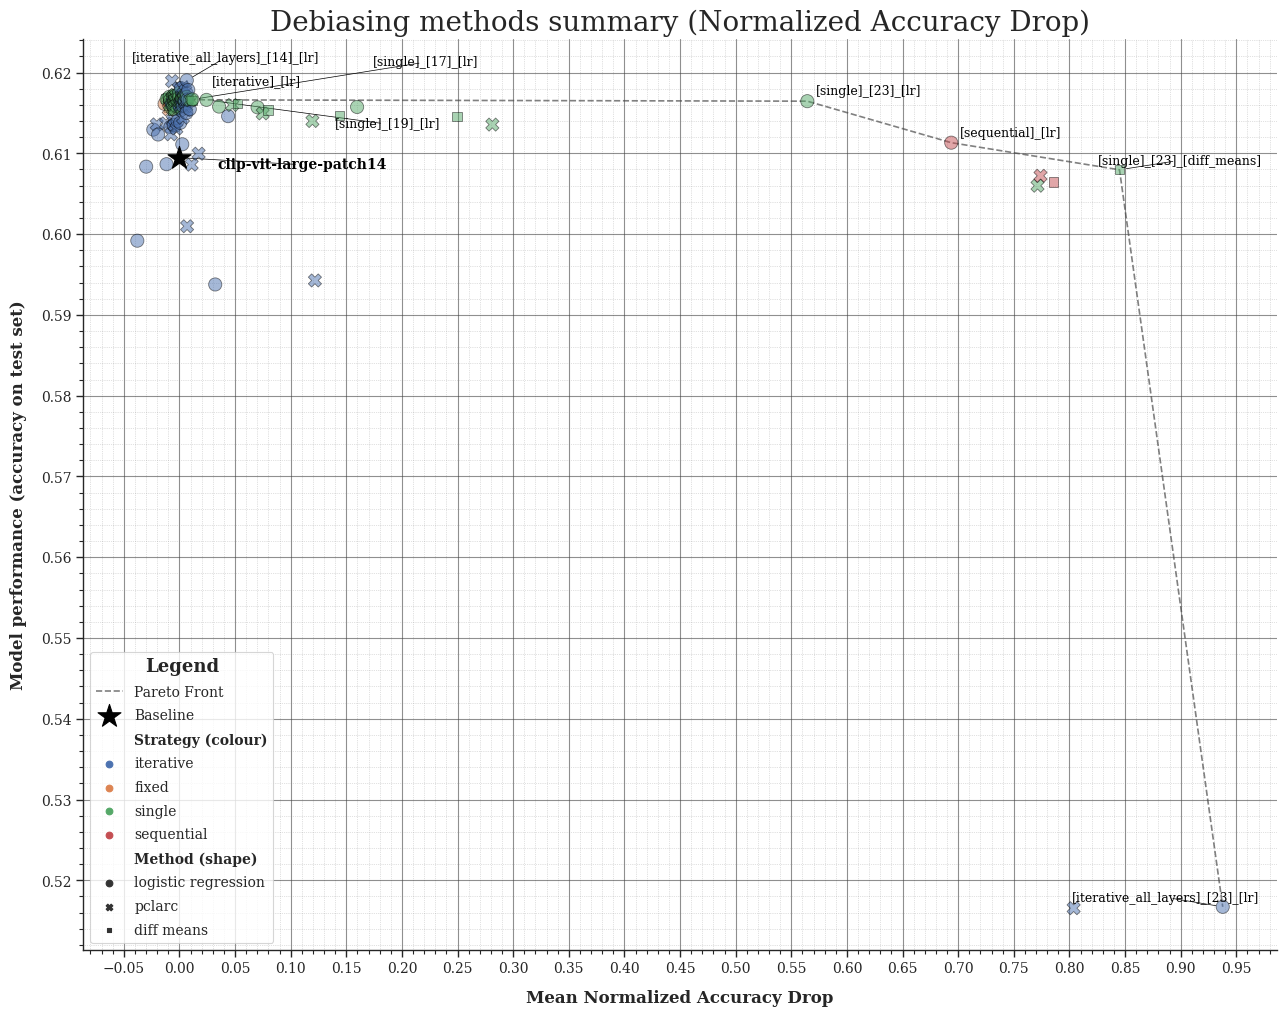

In [184]:
fig, ax = plot_scientific_pareto(
    df=grouped, 
    df_baseline=base_model, 
    x_col='debias_deleted_fraction_mean'
    ,title=r'Debiasing methods summary (Normalized Accuracy Drop)'
    ,x_label='Mean Normalized Accuracy Drop'
    ,y_label='Model performance (accuracy on test set)'
)

# Wyświetlenie lub zapis do pliku wysokiej jakości
plt.show()

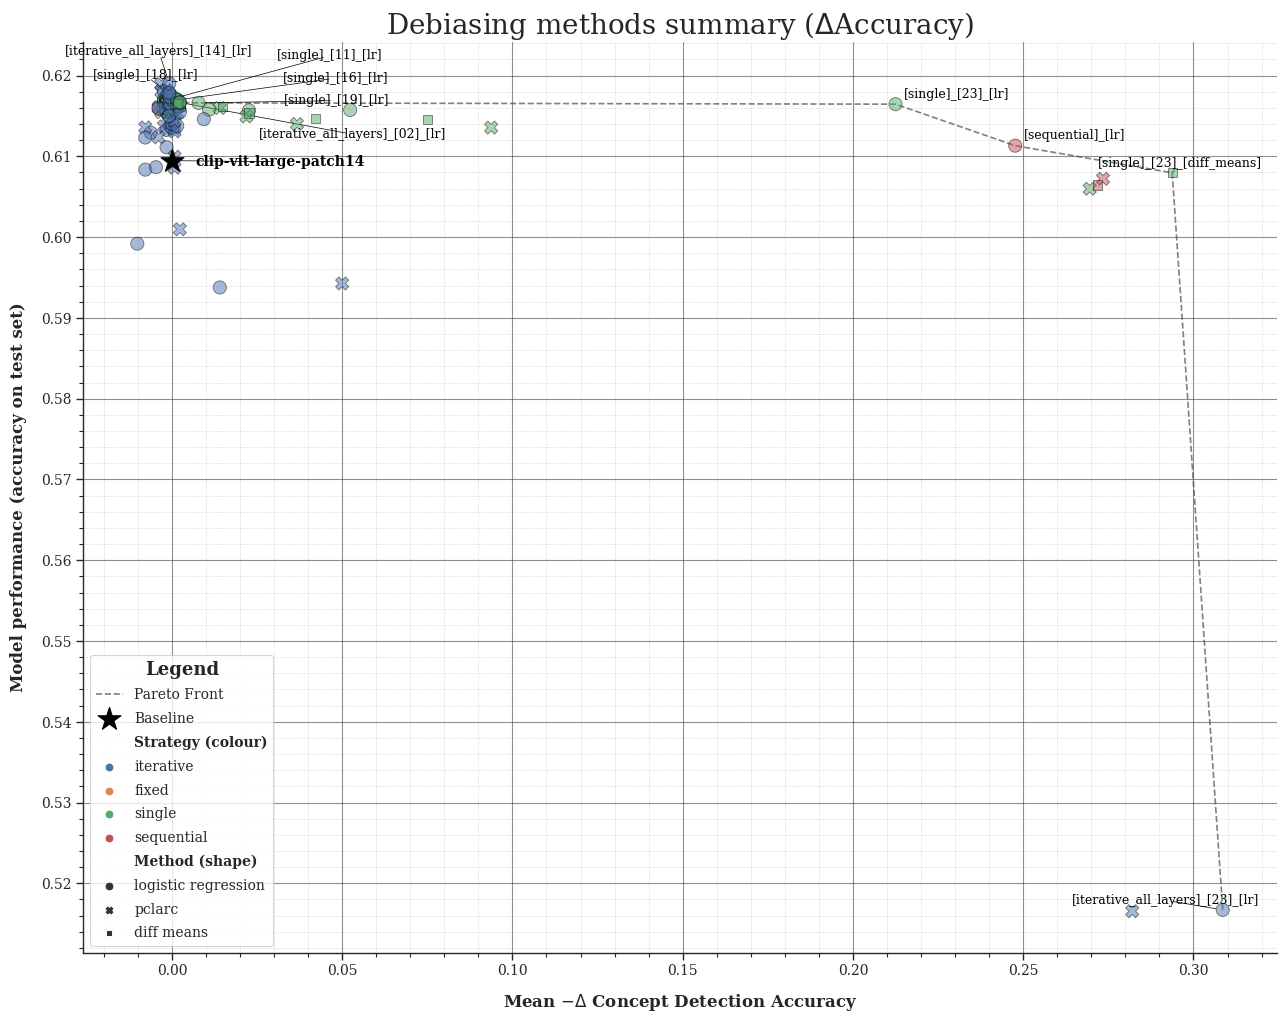

In [185]:
fig, ax = plot_scientific_pareto(
    df=grouped, 
    df_baseline=base_model, 
    x_col='debias_delta_BA_mean'
    ,title=r'Debiasing methods summary ($\Delta$Accuracy)'
    ,x_label=r'Mean $-\Delta$ Concept Detection Accuracy'
    ,y_label='Model performance (accuracy on test set)'
    
)

# Wyświetlenie lub zapis do pliku wysokiej jakości
plt.show()